In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [3]:
#load data
df = pd.read_stata('assignment7.dta')

df.head()

,sex,age,datyear,agelfted,nireland,yearat14,missing_earn,wght,ones,yearat14_2,...,goodhealth,badhealth,unemployed,incsupport,yobirth,drop14,drop15,drop16,educb14,educb15
0,male,63,84.0,14.0,0.0,35.0,0.0,35,1.0,1225.0,...,0.628571,0.000000,0.029412,0.028571,21.0,1.0,0.0,0.0,1.0,1.0
1,female,63,84.0,14.0,0.0,35.0,0.0,16,1.0,1225.0,...,0.750000,0.062500,0.000000,0.062500,21.0,1.0,0.0,0.0,1.0,1.0
2,male,63,84.0,15.0,0.0,35.0,0.0,3,1.0,1225.0,...,0.000000,0.333333,0.000000,0.000000,21.0,1.0,0.0,0.0,0.0,1.0
3,female,63,84.0,15.0,0.0,35.0,0.0,1,1.0,1225.0,...,1.000000,0.000000,0.000000,0.000000,21.0,1.0,0.0,0.0,0.0,1.0
4,male,63,84.0,16.0,0.0,35.0,0.0,2,1.0,1225.0,...,1.000000,0.000000,0.000000,0.000000,21.0,1.0,0.0,0.0,0.0,0.0


In [4]:
df.info()
print("\nSummary Statistics:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30487 entries, 0 to 30486
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sex           30487 non-null  category
 1   age           30487 non-null  int16   
 2   datyear       30487 non-null  float32 
 3   agelfted      30487 non-null  float32 
 4   nireland      30487 non-null  float32 
 5   yearat14      30487 non-null  float32 
 6   missing_earn  30487 non-null  float32 
 7   wght          30487 non-null  int32   
 8   ones          30487 non-null  float32 
 9   yearat14_2    30487 non-null  float32 
 10  yearat14_3    30487 non-null  float32 
 11  yearat14_4    30487 non-null  float32 
 12  age2          30487 non-null  float32 
 13  age3          30487 non-null  float32 
 14  age4          30487 non-null  float32 
 15  lhinc         15555 non-null  float32 
 16  learn         16257 non-null  float32 
 17  linc          9961 non-null   float32 
 18  goodhe

In [5]:
df["cluster_id"] = df.groupby(["yearat14", "nireland"]).ngroup()

df[["yearat14", "nireland", "cluster_id"]].head()

,yearat14,nireland,cluster_id
0,35.0,0.0,0
1,35.0,0.0,0
2,35.0,0.0,0
3,35.0,0.0,0
4,35.0,0.0,0


Question 1: Replicate Figures 4 and 6 from the paper.

In [6]:
#break into regional groups

df_gb = df[df['nireland'] == 0].copy()
df_gb[["yearat14", "nireland"]].drop_duplicates()
df_ni = df[df['nireland'] == 1].copy()
df_ni[["yearat14", "nireland"]].drop_duplicates()
df_gb.info(), df_ni.info()


<class 'pandas.core.frame.DataFrame'>
Index: 22574 entries, 0 to 30103
Data columns (total 29 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sex           22574 non-null  category
 1   age           22574 non-null  int16   
 2   datyear       22574 non-null  float32 
 3   agelfted      22574 non-null  float32 
 4   nireland      22574 non-null  float32 
 5   yearat14      22574 non-null  float32 
 6   missing_earn  22574 non-null  float32 
 7   wght          22574 non-null  int32   
 8   ones          22574 non-null  float32 
 9   yearat14_2    22574 non-null  float32 
 10  yearat14_3    22574 non-null  float32 
 11  yearat14_4    22574 non-null  float32 
 12  age2          22574 non-null  float32 
 13  age3          22574 non-null  float32 
 14  age4          22574 non-null  float32 
 15  lhinc         15555 non-null  float32 
 16  learn         13118 non-null  float32 
 17  linc          9961 non-null   float32 
 18  goodhealth 

(None, None)

In [7]:
#restrict to 32 to 65
# Use parentheses when combining boolean masks and reference the same dataframe (df_gb)
df_gb = df_gb[(df_gb['age'] >= 32) & (df_gb['age'] <= 65) & (df_gb["learn"].notnull())].copy()

# Quick checks
print(f"GB sample after age restriction: {len(df_gb)}")
print(f"Age range after filter: {df_gb['age'].min()} - {df_gb['age'].max()}")
print(f"Missing 'learn' values: {df_gb['learn'].isna().sum()}")


GB sample after age restriction: 13115
Age range after filter: 33 - 64
Missing 'learn' values: 0


In [18]:
#weighted average for individual dots

def wmean(series, weights):
    # compute weighted mean safely (handle NaNs and zero-length)
    mask = series.notnull() & weights.notnull()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

# plot average per cohort, dot per year, grouped by yearat14
# include weighted means for both agelfted and learn (log earnings)
points = (
    df_gb
    .groupby("yearat14")
    .apply(lambda g: pd.Series({
        "agelfted_mean": wmean(g["agelfted"], g["wght"]),
        "learn_mean": wmean(g["learn"], g["wght"]),
        "n": len(g)
    }))
    .reset_index()
)

points.head()


C:\Users\majoa\AppData\Local\Temp\ipykernel_58092\687482927.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,yearat14,agelfted_mean,learn_mean,n
0,35.0,14.957627,8.160411,24.0
1,36.0,14.973214,8.287352,44.0
2,37.0,14.896552,8.218967,61.0
3,38.0,15.086957,8.413887,89.0
4,39.0,14.914894,8.424010,109.0


In [21]:
#separate points before and after 1947
points_before_1947 = points[points["yearat14"] < 47]
points_after_1947 = points[points["yearat14"] >= 47]



In [29]:
#Age left model fits
coef_before_1947 = np.polyfit(points_before_1947["yearat14"], points_before_1947["agelfted_mean"], 4)
poly_before_1947 = np.poly1d(coef_before_1947)

X_before_1947 = np.linspace(points_before_1947["yearat14"].min(), points_before_1947["yearat14"].max(), 100)
y_before_1947 = poly_before_1947(X_before_1947)


coef_after_1947 = np.polyfit(points_after_1947["yearat14"], points_after_1947["agelfted_mean"], 4)
poly_after_1947 = np.poly1d(coef_after_1947)

X_after_1947 = np.linspace(points_after_1947["yearat14"].min(), points_after_1947["yearat14"].max(), 100)
y_after_1947 = poly_after_1947(X_after_1947)


#log of earnings model fit
coef_earn_before_1947 = np.polyfit(points_before_1947["yearat14"], points_before_1947["learn_mean"], 4)
poly_earn_before_1947 = np.poly1d(coef_earn_before_1947)

X_earn_before_1947 = np.linspace(points_before_1947["yearat14"].min(), points_before_1947["yearat14"].max(), 100)
y_earn_before_1947 = poly_earn_before_1947(X_earn_before_1947)


coef_earn_after_1947 = np.polyfit(points_after_1947["yearat14"], points_after_1947["learn_mean"], 4)
poly_earn_after_1947 = np.poly1d(coef_earn_after_1947)

X_earn_after_1947 = np.linspace(points_after_1947["yearat14"].min(), points_after_1947["yearat14"].max(), 100)
y_earn_after_1947 = poly_earn_after_1947(X_earn_after_1947)



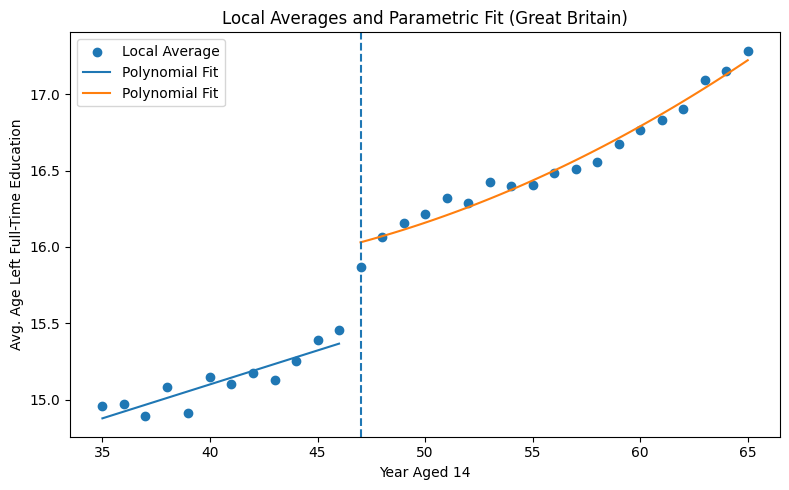

In [27]:
#now we plot

fig, ax = plt.subplots(figsize=(8, 5))

# 1) Dots: local averages
ax.scatter(points["yearat14"], points["agelfted_mean"], label="Local Average")

# 2) Line: polynomial fit
ax.plot(X_before_1947, y_before_1947, label="Polynomial Fit")
ax.plot(X_after_1947, y_after_1947, label="Polynomial Fit")

# 3) Vertical line at the reform year (1947)
ax.axvline(47, linestyle="--")

# Labels and title
ax.set_xlabel("Year Aged 14")
ax.set_ylabel("Avg. Age Left Full-Time Education")
ax.set_title("Local Averages and Parametric Fit (Great Britain)")

ax.legend()

plt.tight_layout()
plt.show()


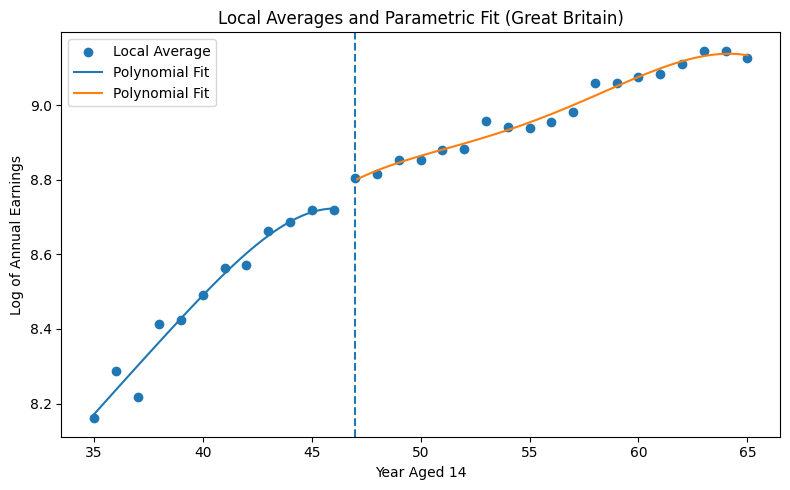

In [31]:
#now we plot

fig, ax = plt.subplots(figsize=(8, 5))

# 1) Dots: local averages
ax.scatter(points["yearat14"], points["learn_mean"], label="Local Average")

# 2) Line: polynomial fit
ax.plot(X_earn_before_1947, y_earn_before_1947, label="Polynomial Fit")
ax.plot(X_earn_after_1947, y_earn_after_1947, label="Polynomial Fit")

# 3) Vertical line at the reform year (1947)
ax.axvline(47, linestyle="--")

# Labels and title
ax.set_xlabel("Year Aged 14")
ax.set_ylabel("Log of Annual Earnings")
ax.set_title("Local Averages and Parametric Fit (Great Britain)")

ax.legend()

plt.tight_layout()
plt.show()

In [37]:
# create variables

df_gb["Z'"] = df_gb["yearat14"] - 47

for power in range(2,5):
    col_name = f"yobirth_pow_{power}"
    df_gb[col_name] = df_gb["yobirth"] ** power

print("GB Region:")
print(df_gb[["Z'", "yobirth_pow_2", "yobirth_pow_3", "yobirth_pow_4"]].head())

# Di is 1 if yearat14 >= 47, else 0
df_gb["Di"] = (df_gb["yearat14"] >= 47).astype(int)

print(df_gb[["yearat14", "Di"]].head(10))


df_gb["Z'Di"] = df_gb["Z'"]* df_gb["Di"]


GB Region:
     Z'  yobirth_pow_2  yobirth_pow_3  yobirth_pow_4
0 -12.0          441.0         9261.0       194481.0
1 -12.0          441.0         9261.0       194481.0
2 -12.0          441.0         9261.0       194481.0
3 -12.0          441.0         9261.0       194481.0
4 -12.0          441.0         9261.0       194481.0
   yearat14  Di
0      35.0   0
1      35.0   0
2      35.0   0
3      35.0   0
4      35.0   0
5      35.0   0
6      35.0   0
7      35.0   0
8      35.0   0
9      35.0   0


In [ ]:
#Build regression models

#GB Model on agelfted first regression
y = df_gb["agelfted"]
X = df_gb[["Z'", "Di", "Z'Di", "yobirth", "yobirth_pow_2", "yobirth_pow_3", "yobirth_pow_4"]]
X = sm.add_constant(X)

print(f"Sample size after dropping NaN: {len(y)}")
print(f"Number of clusters: {df_gb.loc[y.index, 'cluster_id'].nunique()}")

model = sm.WLS(y, X, weights=df_gb["wght"])
results = model.fit(cov_type='cluster', cov_kwds={'groups': df_gb['cluster_id']})

print(results.summary())


#GB Model on agelfted second regression
y = df_gb["Di"]
X = df_gb[["Z'", "yobirth", "yobirth_pow_2", "yobirth_pow_3", "yobirth_pow_4"]]
X = sm.add_constant(X)


Sample size after dropping NaN: 13115
Number of clusters: 31
                            WLS Regression Results                            
Dep. Variable:               agelfted   R-squared:                       0.036
Model:                            WLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                 1.554e+05
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           5.60e-66
Time:                        14:13:15   Log-Likelihood:                -37950.
No. Observations:               13115   AIC:                         7.591e+04
Df Residuals:                   13108   BIC:                         7.597e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

c:\Users\majoa\OneDrive\Desktop\Learning\Grad School\econometrics\assignment_7\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [44]:
#link first stage and reduced form results to get LATE estimates

beta_first = results.params[['drop15']]
beta_second = results.params[['drop15']]

iv_return = beta_second / beta_first
print(f"LATE estimate of return to education: {iv_return}")

KeyError: "None of [Index(['drop15'], dtype='object')] are in the [index]"

In [37]:
#GB Model on log of earnings
y_gb = df_gb["learn"].dropna()
X_gb = df_gb.loc[y_gb.index, ["drop15","c_year", "c_year_pow_2", "c_year_pow_3", "c_year_pow_4"]]
X_gb = sm.add_constant(X_gb)

print(f"Sample size after dropping NaN: {len(y_gb)}")
print(f"Number of clusters: {df_gb.loc[y_gb.index, 'cluster_id'].nunique()}")

model_gb_second = sm.WLS(y_gb, X_gb, weights=df_gb.loc[y_gb.index, "wght"])
results_gb_second = model_gb_second.fit(cov_type='cluster', cov_kwds={'groups': df_gb.loc[y_gb.index, 'cluster_id']})

print(results_gb_second.summary())


Sample size after dropping NaN: 13118
Number of clusters: 31
                            WLS Regression Results                            
Dep. Variable:                  learn   R-squared:                       0.055
Model:                            WLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     759.8
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           1.25e-30
Time:                        11:40:13   Log-Likelihood:                -19302.
No. Observations:               13118   AIC:                         3.862e+04
Df Residuals:                   13112   BIC:                         3.866e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [45]:
from linearmodels.iv import IV2SLS

y_iv = df_gb["learn"].dropna()
X_iv = df_gb.loc[y_iv.index, ["c_year", "c_year_pow_2", "c_year_pow_3", "c_year_pow_4"]]
X_iv = sm.add_constant(X_iv)

# Endogenous regressor:
endog = df_gb.loc[y_iv.index, "agelfted"]

# Instrument:
instrument = df_gb.loc[y_iv.index, "drop15"]

iv_model = IV2SLS(y_iv, X_iv, endog, instrument, weights=df_gb.loc[y_iv.index, "wght"])
iv_results = iv_model.fit(cov_type="clustered", clusters=df_gb.loc[y_iv.index, "cluster_id"])

print(iv_results.summary)


                          IV-2SLS Estimation Summary                          
Dep. Variable:                  learn   R-squared:                      0.1181
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1178
No. Observations:               13118   F-statistic:                    4037.4
Date:                Fri, Nov 21 2025   P-value (F-stat)                0.0000
Time:                        11:50:03   Distribution:                  chi2(5)
Cov. Estimator:             clustered                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
const            7.1258     0.5424     13.137     0.0000      6.0626      8.1889
c_year           0.0162     0.0021     7.559